<a href="https://colab.research.google.com/github/chebil/stat/blob/main/part1/ch01_assignment.ipynb" target="_blank" rel="noopener noreferrer"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1 Assignment: Exploring Global Life Expectancy Data

## Overview

In this assignment, you will apply the concepts learned in Chapter 1 to analyze a real-world dataset. You will:

1. **Load and explore** a public dataset
2. **Clean the data** by handling missing values and data types
3. **Create visualizations** (bar charts, histograms)
4. **Calculate descriptive statistics** (mean, median, standard deviation)
5. **Draw conclusions** based on your analysis

## Dataset: Gapminder Life Expectancy Data

We will use the **Gapminder** dataset, which contains information about countries including:
- Life expectancy
- GDP per capita
- Population
- Continent

This dataset is publicly available and widely used for teaching data analysis.

**Source**: https://www.gapminder.org/data/

---

## Instructions

- Complete all the tasks marked with **TODO**
- Write your code in the provided cells
- Answer the questions in markdown cells
- Make sure your visualizations have proper labels and titles

---

## Part 1: Loading and Exploring the Data (15 points)

First, let's import the necessary libraries and load the dataset.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [2]:
# Load the Gapminder dataset from a public URL
url = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
df = pd.read_csv(url)

# Display the first 10 rows
print("First 10 rows of the dataset:")
df.head(10)

First 10 rows of the dataset:


,country,year,pop,continent,lifeExp,gdpPercap
0,Afghanistan,1952,8425333.0,Asia,28.801,779.445314
1,Afghanistan,1957,9240934.0,Asia,30.332,820.853030
2,Afghanistan,1962,10267083.0,Asia,31.997,853.100710
3,Afghanistan,1967,11537966.0,Asia,34.020,836.197138
4,Afghanistan,1972,13079460.0,Asia,36.088,739.981106
5,Afghanistan,1977,14880372.0,Asia,38.438,786.113360
6,Afghanistan,1982,12881816.0,Asia,39.854,978.011439
7,Afghanistan,1987,13867957.0,Asia,40.822,852.395945
8,Afghanistan,1992,16317921.0,Asia,41.674,649.341395
9,Afghanistan,1997,22227415.0,Asia,41.763,635.341351


### Task 1.1: Explore the Dataset Structure (5 points)

**TODO**: Use appropriate pandas methods to answer the following questions:
1. How many rows and columns does the dataset have?
2. What are the data types of each column?
3. Are there any missing values?

In [4]:
# TODO: Find the shape of the dataset (rows, columns)
# Hint: Use df.shape

# 1) Find the shape of the dataset (rows, columns)
rows, cols = df.shape
print("Number of rows:", rows)
print("Number of columns:", cols)



Number of rows: 1704
Number of columns: 6


In [5]:
# TODO: Display data types and info about the dataset
# Hint: Use df.info() or df.dtypes

print("DataFrame info:")
print(df.info())

print("\nData types of each column:")
print(df.dtypes)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   year       1704 non-null   int64  
 2   pop        1704 non-null   float64
 3   continent  1704 non-null   object 
 4   lifeExp    1704 non-null   float64
 5   gdpPercap  1704 non-null   float64
dtypes: float64(3), int64(1), object(2)
memory usage: 80.0+ KB
None

Data types of each column:
country       object
year           int64
pop          float64
continent     object
lifeExp      float64
gdpPercap    float64
dtype: object


In [6]:
# TODO: Check for missing values in each column
# Hint: Use df.isnull().sum()

print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    0
dtype: int64


### Task 1.2: Understand the Variables (5 points)

**TODO**: For each categorical column, find the unique values.

In [7]:
# TODO: Find unique continents in the dataset
# Hint: Use df['continent'].unique()

print("Unique continents in the dataset:")
print(df['continent'].unique())

Unique continents in the dataset:
['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']


In [8]:
# TODO: Find the range of years covered in the dataset
# Hint: Use df['year'].min() and df['year'].max()

min_year = df['year'].min()
max_year = df['year'].max()

print("Earliest year in the dataset:", min_year)
print("Latest year in the dataset:", max_year)
print("Range of years: {} to {}".format(min_year, max_year))

Earliest year in the dataset: 1952
Latest year in the dataset: 2007
Range of years: 1952 to 2007


In [9]:
# TODO: How many unique countries are in the dataset?
# Hint: Use df['country'].nunique()

num_countries = df['country'].nunique()
print("Number of unique countries in the dataset:", num_countries)

Number of unique countries in the dataset: 142


### Task 1.3: Filter Data for Analysis (5 points)

For the rest of this assignment, we will focus on the most recent year in the dataset.

**TODO**: Create a new DataFrame containing only the data from year 2007.

In [10]:
# TODO: Filter the dataset to include only year 2007
# Hint: df_2007 = df[df['year'] == 2007]

df_2007 = df[df['year'] == 2007]

# Display the shape of the filtered dataset
print(f"Number of countries in 2007: {len(df_2007) if df_2007 is not None else 'Complete the TODO'}")

Number of countries in 2007: 142


---

## Part 2: Data Cleaning (15 points)

Real-world data often contains issues that need to be addressed before analysis. In this section, you will practice data cleaning techniques.

### Task 2.1: Introduce and Handle Missing Values (10 points)

Let's simulate a real-world scenario by introducing some missing values, then handle them appropriately.

In [17]:
# Create a copy of the 2007 data for cleaning practice
df_clean = df_2007.copy()

# Introduce some missing values (simulating real-world data issues)
np.random.seed(42)  # For reproducibility
missing_indices = np.random.choice(df_clean.index, size=10, replace=False)
df_clean.loc[missing_indices[:5], 'lifeExp'] = np.nan
df_clean.loc[missing_indices[5:], 'gdpPercap'] = np.nan

print("Missing values introduced:")
print(df_clean.isnull().sum())

Missing values introduced:
country      0
year         0
pop          0
continent    0
lifeExp      5
gdpPercap    5
dtype: int64


In [18]:
# TODO: Identify which countries have missing life expectancy values
# Hint: df_clean[df_clean['lifeExp'].isnull()]['country']

missing_lifeexp_countries = df_clean[df_clean['lifeExp'].isnull()]['country']

print("Countries with missing life expectancy values:")
print(missing_lifeexp_countries.unique())

Countries with missing life expectancy values:
['Cameroon' 'Hungary' 'Mauritius' 'Oman' 'Turkey']


In [20]:
# TODO: Fill missing 'lifeExp' values with the median life expectancy of their continent
# Hint: Use groupby and transform with a lambda function
# Example: df_clean['lifeExp'] = df_clean.groupby('continent')['lifeExp'].transform(
#              lambda x: x.fillna(x.median()))

df_clean['lifeExp'] = df_clean.groupby('continent')['lifeExp'].transform(
    lambda x: x.fillna(x.median())
)

In [21]:
# TODO: Fill missing 'gdpPercap' values with the median GDP of their continent

print("Remaining missing gdpPercap values:", df_clean['gdpPercap'].isna().sum())

Remaining missing gdpPercap values: 5


In [22]:
# TODO: Verify that there are no more missing values
# Hint: Use df_clean.isnull().sum()
print("Missing values in each column after cleaning:")
print(df_clean.isnull().sum())

Missing values in each column after cleaning:
country      0
year         0
pop          0
continent    0
lifeExp      0
gdpPercap    5
dtype: int64


### Task 2.2: Data Type Validation (5 points)

**TODO**: Create a new column called `pop_millions` that contains the population in millions (divide population by 1,000,000).

In [23]:
# TODO: Create a new column 'pop_millions' = population / 1,000,000
# Round to 2 decimal places using .round(2)

df_clean['pop_millions'] = (df_clean['pop'] / 1_000_000).round(2)

# Display sample of the result
# df_clean[['country', 'pop', 'pop_millions']].head(10)

df_clean[['country', 'pop', 'pop_millions']].head(10)

,country,pop,pop_millions
11,Afghanistan,31889923.0,31.89
23,Albania,3600523.0,3.60
35,Algeria,33333216.0,33.33
47,Angola,12420476.0,12.42
59,Argentina,40301927.0,40.30
71,Australia,20434176.0,20.43
83,Austria,8199783.0,8.20
95,Bahrain,708573.0,0.71
107,Bangladesh,150448339.0,150.45
119,Belgium,10392226.0,10.39


---

## Part 3: Visualization (35 points)

Now let's create visualizations to understand our data better.

### Task 3.1: Bar Chart - Countries per Continent (10 points)

**TODO**: Create a bar chart showing the number of countries in each continent.

Requirements:
- Add a title: "Number of Countries per Continent (2007)"
- Label the x-axis: "Continent"
- Label the y-axis: "Number of Countries"
- Add value labels on top of each bar

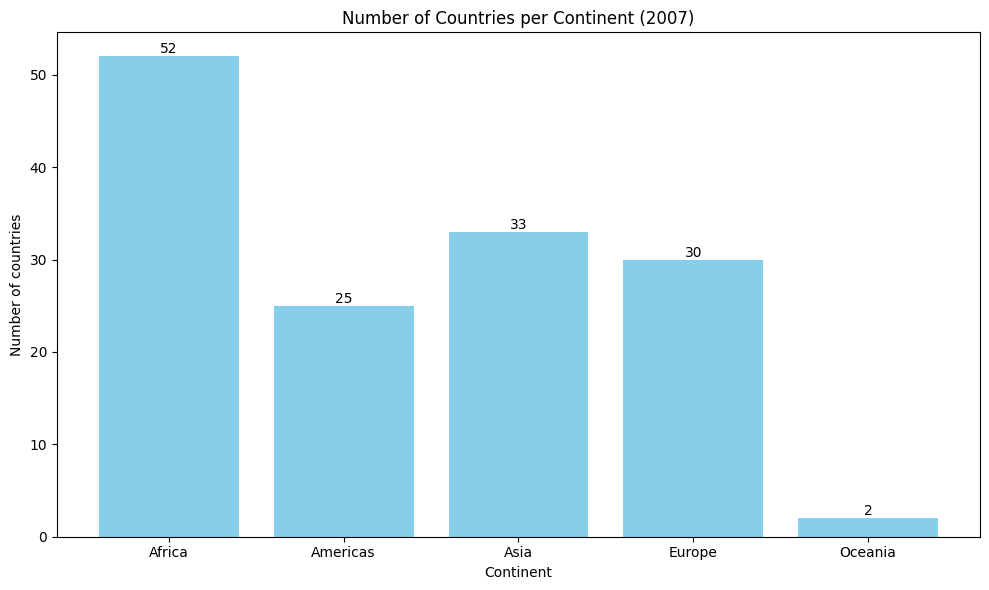

In [24]:
# TODO: Create a bar chart showing countries per continent
# Step 1: Count countries per continent using value_counts()
# Step 2: Create the bar chart using plt.bar()
# Step 3: Add labels and title
# Step 4: Add value labels on bars

plt.figure(figsize=(10, 6))

# Step 1: count countries per continent (based on the filtered 2007 data)
countries_per_continent = df_2007['continent'].value_counts().sort_index()

# Step 2: create the bar chart
continents = countries_per_continent.index
counts = countries_per_continent.values

bars = plt.bar(continents, counts, color='skyblue')

# Step 3: add axis labels and title
plt.xlabel('Continent')
plt.ylabel('Number of countries')
plt.title('Number of Countries per Continent (2007)')

# Step 4: add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )


plt.tight_layout()
plt.show()

### Task 3.2: Histogram - Life Expectancy Distribution (10 points)

**TODO**: Create a histogram showing the distribution of life expectancy across all countries in 2007.

Requirements:
- Use 10 bins
- Add a title: "Distribution of Life Expectancy (2007)"
- Label the x-axis: "Life Expectancy (years)"
- Label the y-axis: "Number of Countries"
- Add a vertical line showing the mean life expectancy

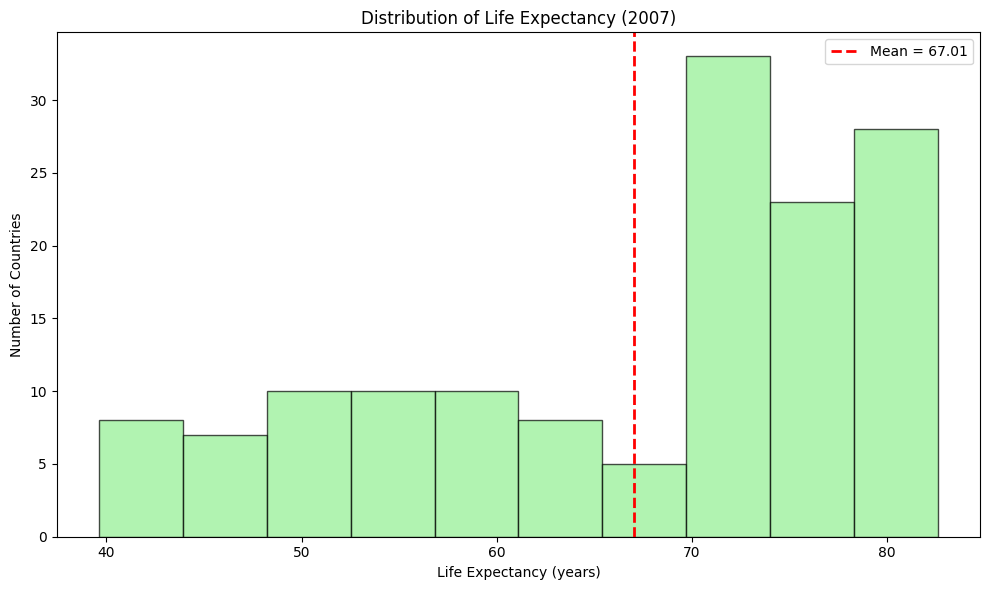

In [40]:
# TODO: Create a histogram of life expectancy
# Step 1: Create histogram using plt.hist()
# Step 2: Calculate mean life expectancy
# Step 3: Add vertical line at the mean using plt.axvline()
# Step 4: Add labels, title, and legend

plt.figure(figsize=(10, 6))

# Step 1: Create histogram using 10 bins
plt.hist(df_2007['lifeExp'], bins=10, color='lightgreen', edgecolor='black', alpha=0.7)

# Step 2: Calculate mean life expectancy
mean_lifeexp = df_2007['lifeExp'].mean()

# Step 3: Add vertical line at the mean
plt.axvline(mean_lifeexp, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {mean_lifeexp:.2f}")

# Step 4: Add labels, title, and legend
plt.title('Distribution of Life Expectancy (2007)')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Number of Countries')
plt.legend()

plt.tight_layout()
plt.show()

### Task 3.3: Conditional Histogram - Life Expectancy by Continent (15 points)

**TODO**: Create separate histograms of life expectancy for each continent to compare distributions.

Requirements:
- Create a figure with 5 subplots (one per continent)
- Use the same x-axis range for all (40 to 85 years)
- Add appropriate titles and labels

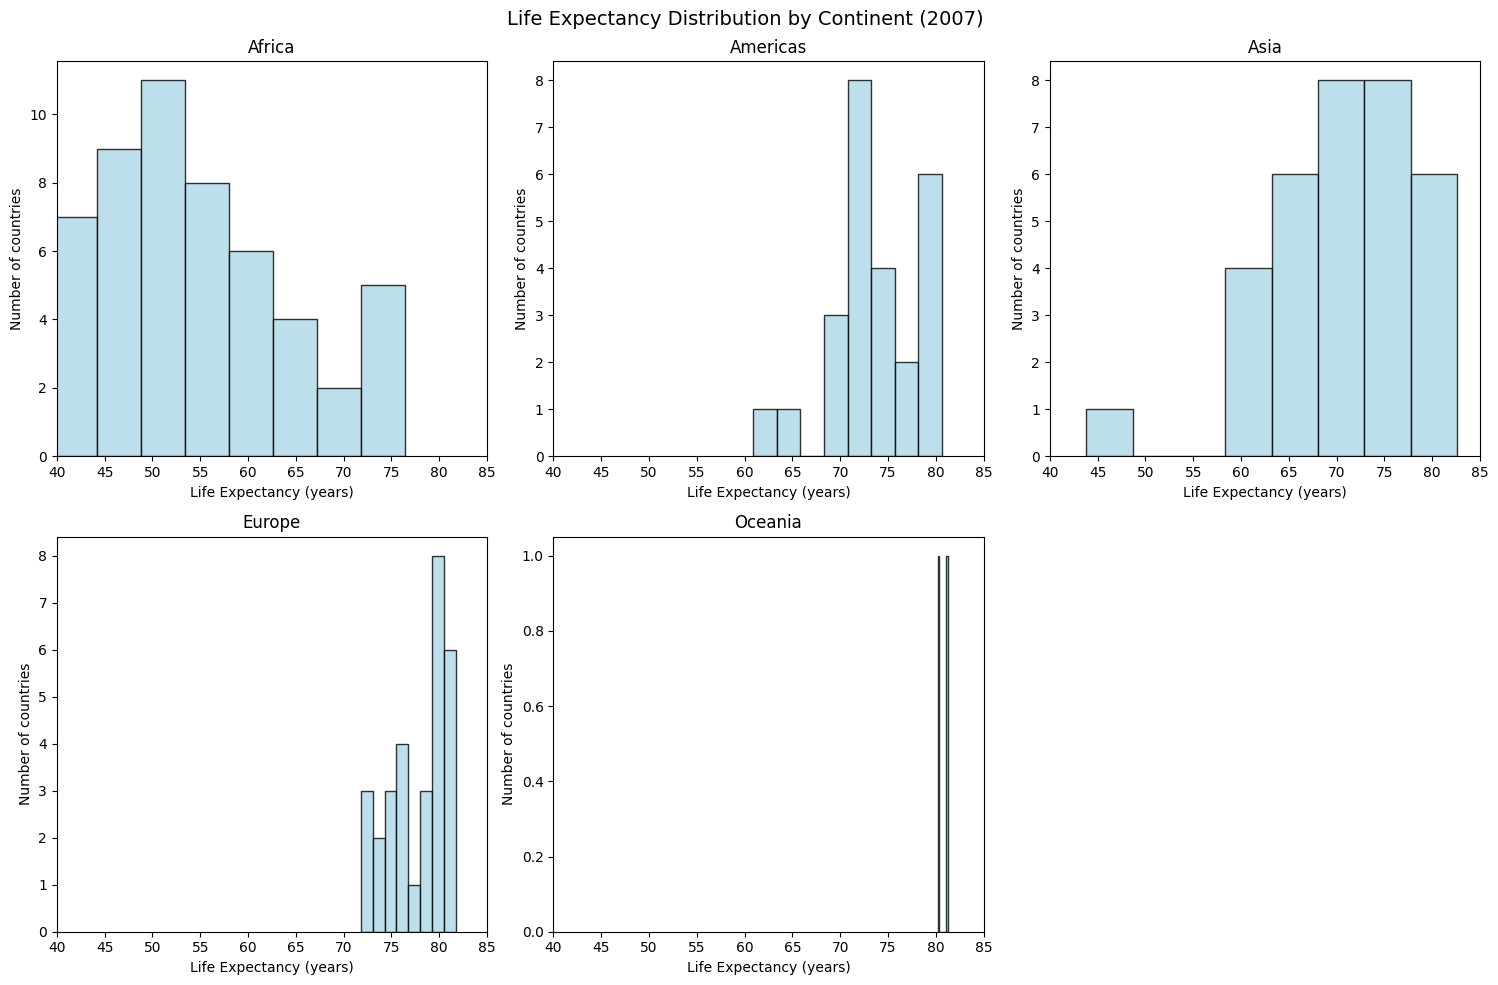

In [39]:
# TODO: Create conditional histograms by continent
# Hint: Use plt.subplots() to create multiple plots
# Loop through continents and create a histogram for each

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()  # Flatten to make indexing easier

# Get the list of continents (one subplot per continent)
continents = sorted(df_2007['continent'].unique())

for i, cont in enumerate(continents):
    ax = axes[i]

    # Filter data for this continent in 2007
    data_cont = df_2007[df_2007['continent'] == cont]['lifeExp']

    # Create histogram
    ax.hist(data_cont, bins=8, color='lightblue', edgecolor='black', alpha=0.8)

    # Set title and labels
    ax.set_title(cont)
    ax.set_xlabel('Life Expectancy (years)')
    ax.set_ylabel('Number of countries')

    # Use the same x-axis range for all plots
    ax.set_xlim(40, 85)

# Hide the unused 6th subplot (we only have 5 continents)
axes[5].set_visible(False)

plt.suptitle('Life Expectancy Distribution by Continent (2007)', fontsize=14)
plt.tight_layout()
plt.show()

---

## Part 4: Descriptive Statistics (20 points)

Calculate and interpret key statistics for the data.

### Task 4.1: Summary Statistics (10 points)

**TODO**: Calculate the following statistics for life expectancy in 2007:
- Mean
- Median
- Standard deviation
- Minimum and Maximum
- Range (Max - Min)

In [27]:
# TODO: Calculate descriptive statistics for life expectancy
# Use numpy or pandas methods: np.mean(), np.median(), np.std(), etc.

life_exp = df_clean['lifeExp']

# Calculate statistics
mean_life = df_2007['lifeExp'].mean()      # TODO: Calculate mean
median_life = df_2007['lifeExp'].median()  # TODO: Calculate median
std_life = df_2007['lifeExp'].std()        # TODO: Calculate standard deviation
min_life = df_2007['lifeExp'].min()        # TODO: Calculate minimum
max_life = df_2007['lifeExp'].max()        # TODO: Calculate maximum
range_life = max_life - min_life           # TODO: Calculate range

print("Life Expectancy Statistics (2007):")
print("="*40)
print(f"Mean:               {mean_life:.2f} years" if mean_life else "TODO")
print(f"Median:             {median_life:.2f} years" if median_life else "TODO")
print(f"Standard Deviation: {std_life:.2f} years" if std_life else "TODO")
print(f"Minimum:            {min_life:.2f} years" if min_life else "TODO")
print(f"Maximum:            {max_life:.2f} years" if max_life else "TODO")
print(f"Range:              {range_life:.2f} years" if range_life else "TODO")

Life Expectancy Statistics (2007):
Mean:               67.01 years
Median:             71.94 years
Standard Deviation: 12.07 years
Minimum:            39.61 years
Maximum:            82.60 years
Range:              42.99 years


### Task 4.2: Statistics by Continent (10 points)

**TODO**: Calculate the mean and standard deviation of life expectancy for each continent.

In [28]:
# TODO: Calculate mean and std of life expectancy by continent
# Hint: Use df_clean.groupby('continent')['lifeExp'].agg(['mean', 'std'])

# continent_stats = ...
continent_stats = df_clean.groupby('continent')['lifeExp'].agg(['mean', 'std'])

# Display the results sorted by mean life expectancy
# continent_stats.sort_values('mean', ascending=False)
continent_stats_sorted = continent_stats.sort_values('mean', ascending=False)
continent_stats_sorted

,mean,std
continent,,
Oceania,80.719500,0.729027
Europe,78.084700,2.645387
Americas,73.608120,4.440948
Asia,70.624076,7.919784
Africa,54.471846,9.276407


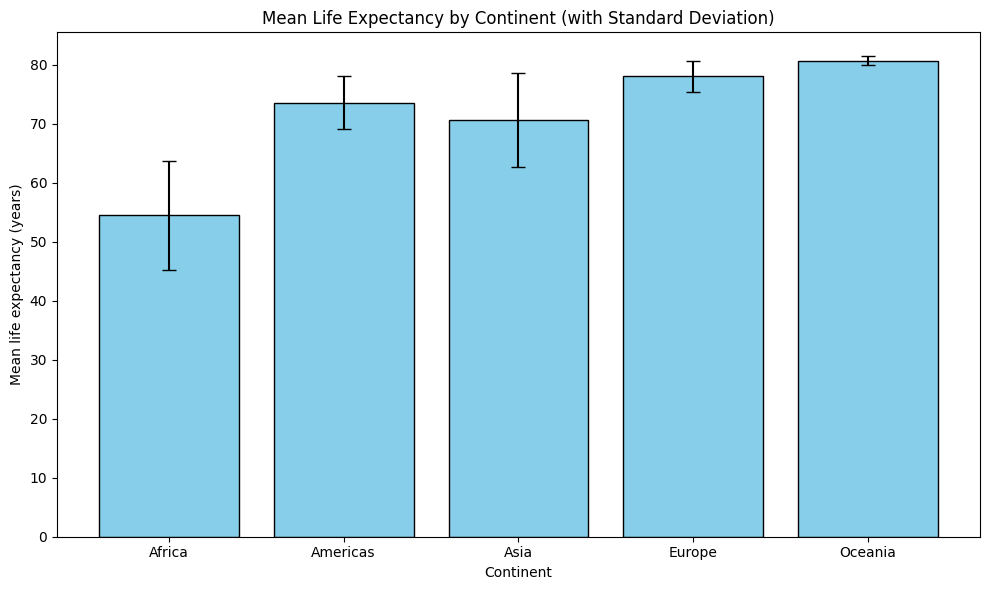

In [29]:
# TODO: Create a bar chart comparing mean life expectancy across continents
# Include error bars showing the standard deviation
# Hint: Use plt.bar() with yerr parameter

plt.figure(figsize=(10, 6))

# Use the statistics computed earlier
# continent_stats should have columns: 'mean' and 'std'
continents = continent_stats.index
means = continent_stats['mean'].values
stds = continent_stats['std'].values

# Create bar chart with error bars
plt.bar(continents, means, yerr=stds, capsize=5, color='skyblue', edgecolor='black')

# Add labels and title
plt.xlabel('Continent')
plt.ylabel('Mean life expectancy (years)')
plt.title('Mean Life Expectancy by Continent (with Standard Deviation)')

plt.tight_layout()
plt.show()

---

## Part 5: Analysis and Conclusions (15 points)

Based on your analysis, answer the following questions.

### Question 5.1: Distribution Shape (5 points)

**TODO**: Look at your histogram from Task 3.2. Describe the shape of the life expectancy distribution.

Consider:
- Is it symmetric or skewed?
- Is it unimodal (one peak) or bimodal (two peaks)?
- Are there any outliers?

**Your Answer:**

> The distribution of life expectancy in 2007 is right‑skewed, with most countries having relatively high life expectancy and a tail extending toward lower values. It appears roughly unimodal, with a single main peak around the high‑60s to low‑70s. There are a few countries with noticeably lower life expectancy than the rest, which can be considered potential outliers.


### Question 5.2: Mean vs Median (5 points)

**TODO**: Compare the mean and median life expectancy you calculated.

- Which one is larger?
- What does this tell you about the distribution?
- Which measure would you use to describe the "typical" life expectancy and why?

**Your Answer:**

*You can write your answer like this in Markdown:

> The median life expectancy (71.94 years) is larger than the mean life expectancy (67.01 years). This indicates that the distribution is right‑skewed, with a tail of countries that have relatively low life expectancy pulling the mean downward. Because of this skew and the presence of low‑life‑expectancy countries, the median is a better measure of the “typical” life expectancy than the mean, since it is less affected by extreme values.



### Question 5.3: Continental Differences (5 points)

**TODO**: Based on your analysis of life expectancy by continent:

1. Which continent has the highest average life expectancy?
2. Which continent has the most variability (highest standard deviation)?
3. What factors might explain these differences?

**Your Answer:**

> Based on the summary statistics and histograms, Europe and Oceania have the highest average life expectancy, followed closely by the Americas and parts of Asia, while Africa has the lowest average life expectancy. Africa also shows the greatest variability (highest spread of values), with countries ranging from very low to moderate life expectancy, whereas Europe and Oceania are more tightly clustered at high values. These differences are likely driven by factors such as differences in economic development, healthcare quality and access, education, nutrition, and the burden of infectious diseases and conflict, which tend to be more severe in many African countries and less so in Europe, Oceania, and richer parts of the Americas and Asia.



---

## Bonus Challenge (10 extra points)

For extra credit, complete the following challenge.

### Bonus: Temporal Analysis

**TODO**: Create a line plot showing how the average life expectancy has changed over time for each continent.

Requirements:
- Calculate mean life expectancy by year and continent
- Create a line plot with one line per continent
- Use different colors for each continent
- Add a legend
- Add appropriate title and labels

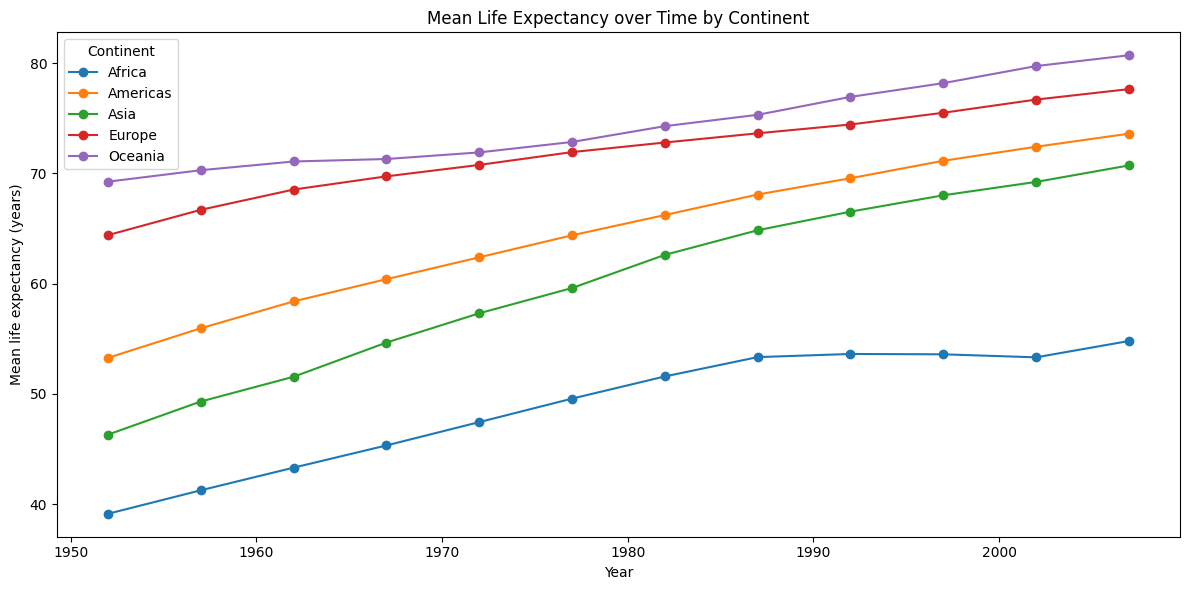

In [35]:
# BONUS: Create a line plot of life expectancy over time by continent
# Hint: Use the original df (not df_2007)
# Group by year and continent, then plot
life_by_year_cont = (
    df.groupby(['year', 'continent'])['lifeExp']
      .mean()
      .reset_index()
)

plt.figure(figsize=(12, 6))

# Create a line plot with one line per continent
continents = life_by_year_cont['continent'].unique()

for cont in continents:
    subset = life_by_year_cont[life_by_year_cont['continent'] == cont]
    plt.plot(
        subset['year'],
        subset['lifeExp'],
        marker='o',
        label=cont
    )

# Add title and labels
plt.title('Mean Life Expectancy over Time by Continent')
plt.xlabel('Year')
plt.ylabel('Mean life expectancy (years)')

# Add legend
plt.legend(title='Continent')

plt.tight_layout()
plt.show()

### Bonus Question:

What trends do you observe in the line plot? Has the gap between continents increased or decreased over time?

**Your Answer:**

> The line plot shows that mean life expectancy increased over time in all continents. Africa started with the lowest life expectancy and remained the lowest throughout the period, while Oceania and Europe consistently had the highest values. The gap between continents appears to have decreased somewhat over time because Asia and the Americas made strong gains, although a noticeable difference still remains between Africa and the higher-life-expectancy continents.



---

## Submission Checklist

Before submitting, make sure you have:

- [ ] Completed all TODO tasks
- [ ] Run all cells from top to bottom without errors
- [ ] Added titles and labels to all visualizations
- [ ] Written answers to all analysis questions
- [ ] Saved your notebook

**Total Points: 100 (+ 10 bonus)**

| Section | Points |
|---------|--------|
| Part 1: Loading and Exploring | 15 |
| Part 2: Data Cleaning | 15 |
| Part 3: Visualization | 35 |
| Part 4: Descriptive Statistics | 20 |
| Part 5: Analysis and Conclusions | 15 |
| Bonus | 10 |

---

**Good luck!** 🎉